## ACCESO Y CREACIÓN DE DATASET DE NOTICIAS ##

# Celda #1: Librerías #

In [1]:
#!pip install gnews pandas newspaper3k langdetect openpyxl
import pandas as pd
from gnews import GNews
from newspaper import Article
from langdetect import detect
from datetime import datetime
import time

In [ ]:
#Configuración de la Conexión a Google News
google_news = GNews(
    language='es',
    country='CO',
    period='7d',          # Últimos 30 días
    max_results=100        # Ajustable
)
# Definición de Términos
queries = [
    "energía Colombia",
    "sector energético Colombia",
    "mercado eléctrico Colombia",
    "mercado mayorista de energía Colombia",
    "bolsa de energía Colombia",
    "precio energía Colombia",
    "demanda de energía Colombia",
    "oferta de energía Colombia",
    "generación eléctrica Colombia",
    "XM operador del mercado Colombia",

    "mercado de futuros energía Colombia",
    "contratos de energía Colombia",
    "futuros de energía Colombia",
    "precio futuro de la energía Colombia",
    "cobertura de precios energía Colombia",
    "riesgo precio energía Colombia",
    "volatilidad del precio de la energía Colombia",

    "CREG energía Colombia",
    "regulación del mercado eléctrico Colombia",
    "política energética Colombia",
    "tarifas de energía Colombia",
    "reforma del sector eléctrico Colombia",
    "normatividad energética Colombia",

    "fenómeno del Niño Colombia energía",
    "fenómeno de La Niña Colombia energía",
    "El Niño Colombia electricidad",
    "La Niña Colombia electricidad",
    "sequía Colombia energía",
    "lluvias Colombia generación hidroeléctrica",
    "niveles de embalses Colombia",
    "hidrología embalses Colombia",
    "crisis energética Colombia",

    "energías renovables Colombia",
    "energía solar Colombia",
    "energía eólica Colombia",
    "transición energética Colombia",
    "generación renovable Colombia",
    "matriz energética Colombia"
]
# "sector energético Colombia",
# "mercado eléctrico Colombia",
# "precio energía Colombia",
# "economía Colombia",
# "inflación Colombia",
# "crecimiento económico Colombia",
# "mercado financiero Colombia"
# temporadas de lluvias y sequía en Colombia

In [3]:
# Creación del Dataset #

In [4]:
# Recolección y estructuración del dataset
data = []

for query in queries:
    print(f"\nBuscando noticias sobre: {query}")
    noticias = google_news.get_news(query)
    print("Noticias encontradas:", len(noticias))
    data.append(noticias)

    #for noticia in noticias:
        #texto = descargar_articulo(noticia["url"])
        #if texto is None:
            #continue

        #registro = {
        #    "Fecha_Rec": datetime.now().strftime("%Y-%m-%d"),
        #    "Query": query,
        #    "Titulo": noticia.get("title"),
        #    "Fuente": noticia.get("publisher", {}).get("title"),
        #    "Fecha": noticia.get("published date"),
        #    "url": noticia.get("url"),
        #    "contenido": texto
        #}

        #data.append(registro)
        #time.sleep(1)


Buscando noticias sobre: energía Colombia


KeyboardInterrupt: 

In [14]:
import requests

url = data[0][2]["url"].split("?")[0]

headers = {
    "User-Agent": (
        "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/121.0.0.0 Safari/537.36"
    ),
    "Accept": "text/html"
}

resp = requests.get(url, headers=headers, allow_redirects=True, timeout=10)

print(resp)

<Response [200]>


In [4]:
def generar_ventanas_mensuales(fecha_inicio, fecha_fin):
    ventanas = []
    actual = fecha_inicio

    while actual < fecha_fin:
        if actual.month == 12:
            siguiente = date(actual.year + 1, 1, 1)
        else:
            siguiente = date(actual.year, actual.month + 1, 1)

        ventanas.append((actual, siguiente))
        actual = siguiente

    return ventanas


fecha_inicio = date(2015, 1, 1)
fecha_fin = date.today()

ventanas = generar_ventanas_mensuales(fecha_inicio, fecha_fin)
len(ventanas)


134

# Descarga Masiva por Baches #

In [ ]:
data = []

for query in queries:
    print(f"\n🔎 Query: {query}")

    for inicio, fin in ventanas:
        print(f"  ⏳ {inicio} → {fin}")

        google_news.start_date = inicio
        google_news.end_date = fin

        try:
            noticias = google_news.get_news(query)
        except Exception as e:
            print("   ⚠️ Error:", e)
            continue

        for noticia in noticias:
            registro = {
                "Query": query,
                "Titulo": noticia.get("title"),
                "Fuente": noticia.get("publisher", {}).get("title"),
                "Fecha": noticia.get("published date"),
                "url": noticia.get("url")
            }
            data.append(registro)

        time.sleep(1)  # MUY IMPORTANTE para evitar bloqueos



🔎 Query: energía Colombia
  ⏳ 2015-01-01 → 2015-02-01


C:\Users\Jhon Fernando Tascón\AppData\Local\Temp\ipykernel_3188\2475053798.py:13: UserWarning: 
Period (30d) will be ignored in favour of the start and end dates
  noticias = google_news.get_news(query)


  ⏳ 2015-02-01 → 2015-03-01


c:\Users\Public\miniconda3\envs\mipython\Lib\site-packages\gnews\gnews.py:128: UserWarning: The start and end dates should be at least 1 day apart.
  warnings.warn("The start and end dates should be at least 1 day apart.")


  ⏳ 2015-03-01 → 2015-04-01
  ⏳ 2015-04-01 → 2015-05-01
  ⏳ 2015-05-01 → 2015-06-01
  ⏳ 2015-06-01 → 2015-07-01
  ⏳ 2015-07-01 → 2015-08-01
  ⏳ 2015-08-01 → 2015-09-01
  ⏳ 2015-09-01 → 2015-10-01
  ⏳ 2015-10-01 → 2015-11-01
  ⏳ 2015-11-01 → 2015-12-01
  ⏳ 2015-12-01 → 2016-01-01
  ⏳ 2016-01-01 → 2016-02-01
  ⏳ 2016-02-01 → 2016-03-01
  ⏳ 2016-03-01 → 2016-04-01
  ⏳ 2016-04-01 → 2016-05-01
  ⏳ 2016-05-01 → 2016-06-01
  ⏳ 2016-06-01 → 2016-07-01
  ⏳ 2016-07-01 → 2016-08-01
  ⏳ 2016-08-01 → 2016-09-01
  ⏳ 2016-09-01 → 2016-10-01
  ⏳ 2016-10-01 → 2016-11-01
  ⏳ 2016-11-01 → 2016-12-01
  ⏳ 2016-12-01 → 2017-01-01
  ⏳ 2017-01-01 → 2017-02-01
  ⏳ 2017-02-01 → 2017-03-01
  ⏳ 2017-03-01 → 2017-04-01
  ⏳ 2017-04-01 → 2017-05-01
  ⏳ 2017-05-01 → 2017-06-01
  ⏳ 2017-06-01 → 2017-07-01
  ⏳ 2017-07-01 → 2017-08-01
  ⏳ 2017-08-01 → 2017-09-01
  ⏳ 2017-09-01 → 2017-10-01
  ⏳ 2017-10-01 → 2017-11-01
  ⏳ 2017-11-01 → 2017-12-01
  ⏳ 2017-12-01 → 2018-01-01
  ⏳ 2018-01-01 → 2018-02-01
  ⏳ 2018-02-01 → 201

In [4]:
ruta = "noticias_energia_CO_limpio_v1.csv"
data = pd.read_csv(ruta)

# Dataset crudo #

In [6]:
df_raw = pd.DataFrame(data)
print("\nTotal de noticias recolectadas (RAW):", df_raw.shape[0])
df_raw.head()


Total de noticias recolectadas (RAW): 13959


,Query,Titulo,Fuente,Fecha,url,Hora,Año,Mes,Dia,Dia_semana
0,energía Colombia,Llega el agua para La Guajira a traves de exca...,Minvivienda,2015-01-17,https://news.google.com/rss/articles/CBMiwAFBV...,00:00:00,2015,Enero,17,Sábado
1,energía Colombia,Reforma tributaria - Ley 1739 de 2014 - Hollan...,Holland & Knight,2015-01-27,https://news.google.com/rss/articles/CBMilgFBV...,00:00:00,2015,Enero,27,Martes
2,energía Colombia,"""Hidrosogamoso nos aleja de un racionamiento d...",Vanguardia,2015-01-15,https://news.google.com/rss/articles/CBMixAFBV...,00:00:00,2015,Enero,15,Jueves
3,energía Colombia,La colombiana Edemsa ganó contrato de energía ...,Semana.com,2015-01-25,https://news.google.com/rss/articles/CBMisAFBV...,00:00:00,2015,Enero,25,Domingo
4,energía Colombia,"A falta de melaza para el ganado, ¿bueno es el...",CONtexto Ganadero,2015-01-19,https://news.google.com/rss/articles/CBMirAFBV...,00:00:00,2015,Enero,19,Lunes


# Creación Dataset Limpio #

In [7]:
# 1. Copia del DataFrame original
df_final = df_raw.copy()

# 2. Conversión de fecha (formato Google News)
df_final['Fecha'] = pd.to_datetime(df_final['Fecha'], utc=True, errors='coerce')

# 3. Crear columna Hora (antes de eliminarla de Fecha)
df_final['Hora'] = df_final['Fecha'].dt.strftime('%H:%M:%S')

# 4. Dejar Fecha únicamente como fecha (sin hora)
df_final['Fecha'] = df_final['Fecha'].dt.date
df_final['Fecha'] = pd.to_datetime(df_final['Fecha'])

# 5. Diccionarios para español
dias = {
    'Monday': 'Lunes', 'Tuesday': 'Martes', 'Wednesday': 'Miércoles',
    'Thursday': 'Jueves', 'Friday': 'Viernes',
    'Saturday': 'Sábado', 'Sunday': 'Domingo'
}

meses = {
    'January': 'Enero', 'February': 'Febrero', 'March': 'Marzo',
    'April': 'Abril', 'May': 'Mayo', 'June': 'Junio',
    'July': 'Julio', 'August': 'Agosto', 'September': 'Septiembre',
    'October': 'Octubre', 'November': 'Noviembre', 'December': 'Diciembre'
}

# 6. Variables temporales
df_final['Año'] = df_final['Fecha'].dt.year
df_final['Mes'] = df_final['Fecha'].dt.month_name().map(meses)
df_final['Dia'] = df_final['Fecha'].dt.day_name().map(dias)

# 7. Eliminación de duplicados
df_final = df_final.drop_duplicates(
    subset=['Titulo', 'Fuente', 'Fecha']
).reset_index(drop=True)

# 8. Limpieza mínima
df_final = df_final.dropna(subset=['Titulo', 'Fecha'])



In [8]:
df_final.tail()

,Query,Titulo,Fuente,Fecha,url,Hora,Año,Mes,Dia,Dia_semana
13447,XM CREG operación mercado eléctrico Colombia,Gobierno adoptó medidas para evitar el desabas...,Infobae,2025-09-17,https://news.google.com/rss/articles/CBMi6gFBV...,00:00:00,2025,Septiembre,Miércoles,Miércoles
13448,XM CREG operación mercado eléctrico Colombia,Gobierno instala de manera permanente la Comis...,Ministerio de Minas y Energía,2025-10-09,https://news.google.com/rss/articles/CBMiwwJBV...,00:00:00,2025,Octubre,Jueves,Jueves
13449,XM CREG operación mercado eléctrico Colombia,Auditoría le da la razón a XM sobre cumplimien...,Valora Analitik,2025-10-08,https://news.google.com/rss/articles/CBMiuwFBV...,00:00:00,2025,Octubre,Miércoles,Miércoles
13450,XM CREG operación mercado eléctrico Colombia,Contraloría detectó pagos sin entregas en cont...,El Espectador,2025-12-23,https://news.google.com/rss/articles/CBMiwwFBV...,00:00:00,2025,Diciembre,Martes,Martes
13451,XM CREG operación mercado eléctrico Colombia,Contraloría detecta millonario detrimento fisc...,Agencia de Periodismo Investigativo,2025-12-23,https://news.google.com/rss/articles/CBMi4gFBV...,00:00:00,2025,Diciembre,Martes,Martes


In [9]:
df_final.to_csv("noticias_energia_CO_limpio_v1.csv", index=False)


# Nuevas Querys #

In [4]:
queries_nuevas = [
    "niveles embalses SIN Colombia XM",
    "aportaciones hídricas sistema interconectado nacional Colombia",
    "índice ENFICC generación hidroeléctrica Colombia",
    "alerta racionamiento energía Colombia fenómeno del Niño",
    "déficit hídrico generación eléctrica Colombia",
    "probabilidad racionamiento eléctrico Colombia 2026",
    "reservas hídricas XM reporte semanal",
    "precio bolsa energía XM histórico Colombia",
    "precio spot energía Colombia variación diaria",
    "precio escasez CREG Colombia actualización",
    "componente restricciones precio energía Colombia",
    "cargo por confiabilidad impacto tarifa energía Colombia",
    "volatilidad precio energía mercado mayorista Colombia",
    "incremento precio energía usuarios no regulados Colombia",
    "resolución CREG mercado mayorista energía",
    "modificación cargo por confiabilidad CREG",
    "reforma mercado eléctrico colombiano",
    "subastas cargo por confiabilidad Colombia",
    "regulación contratos bilaterales energía Colombia",
    "medidas gobierno crisis energética Colombia",
    "intervención tarifaria sector eléctrico Colombia",
    "crecimiento demanda energía Colombia UPME",
    "proyección demanda eléctrica Colombia 2026",
    "consumo energía sector industrial Colombia",
    "demanda máxima SIN Colombia récord",
    "racionamiento industrial energía Colombia",
    "contratos bilaterales energía Colombia precios",
    "precio contratos largo plazo energía Colombia",
    "mercado derivados energía Colombia",
    "coberturas precio energía Colombia industriales",
    "estrategias compra energía usuarios no regulados",
    "riesgo precio energía contratos Colombia",
    "hidrología embalses generación hidroeléctrica Colombia",
    "precio de escasez confiabilidad sistema eléctrico Colombia"
]


# Nueva Recolección #

In [5]:
data_new = []

for query in queries_nuevas:
    print(f"\n🔎 Query: {query}")

    for inicio, fin in ventanas:
        print(f"  ⏳ Ventana: {inicio} → {fin}")

        # Configurar ventana temporal
        google_news.start_date = inicio
        google_news.end_date = fin

        try:
            noticias = google_news.get_news(query)
        except Exception as e:
            print(f"   ⚠️ Error en ventana {inicio} → {fin}: {e}")
            continue

        # Procesar noticias
        for noticia in noticias:
            registro = {
                "Query": query,
                "Titulo": noticia.get("title"),
                "Fuente": noticia.get("publisher", {}).get("title"),
                "Fecha": noticia.get("published date"),
                "url": noticia.get("url")
            }
            data_new.append(registro)

        # Pausa para evitar bloqueos
        time.sleep(1)




🔎 Query: niveles embalses SIN Colombia XM
  ⏳ Ventana: 2015-01-01 → 2015-02-01


C:\Users\Jhon Fernando Tascón\AppData\Local\Temp\ipykernel_16900\145000320.py:14: UserWarning: 
Period (30d) will be ignored in favour of the start and end dates
  noticias = google_news.get_news(query)


  ⏳ Ventana: 2015-02-01 → 2015-03-01


c:\Users\Public\miniconda3\envs\mipython\Lib\site-packages\gnews\gnews.py:128: UserWarning: The start and end dates should be at least 1 day apart.
  warnings.warn("The start and end dates should be at least 1 day apart.")


  ⏳ Ventana: 2015-03-01 → 2015-04-01
  ⏳ Ventana: 2015-04-01 → 2015-05-01
  ⏳ Ventana: 2015-05-01 → 2015-06-01
  ⏳ Ventana: 2015-06-01 → 2015-07-01
  ⏳ Ventana: 2015-07-01 → 2015-08-01
  ⏳ Ventana: 2015-08-01 → 2015-09-01
  ⏳ Ventana: 2015-09-01 → 2015-10-01
  ⏳ Ventana: 2015-10-01 → 2015-11-01
  ⏳ Ventana: 2015-11-01 → 2015-12-01
  ⏳ Ventana: 2015-12-01 → 2016-01-01
  ⏳ Ventana: 2016-01-01 → 2016-02-01
  ⏳ Ventana: 2016-02-01 → 2016-03-01
  ⏳ Ventana: 2016-03-01 → 2016-04-01
  ⏳ Ventana: 2016-04-01 → 2016-05-01
  ⏳ Ventana: 2016-05-01 → 2016-06-01
  ⏳ Ventana: 2016-06-01 → 2016-07-01
  ⏳ Ventana: 2016-07-01 → 2016-08-01
  ⏳ Ventana: 2016-08-01 → 2016-09-01
  ⏳ Ventana: 2016-09-01 → 2016-10-01
  ⏳ Ventana: 2016-10-01 → 2016-11-01
  ⏳ Ventana: 2016-11-01 → 2016-12-01
  ⏳ Ventana: 2016-12-01 → 2017-01-01
  ⏳ Ventana: 2017-01-01 → 2017-02-01
  ⏳ Ventana: 2017-02-01 → 2017-03-01
  ⏳ Ventana: 2017-03-01 → 2017-04-01
  ⏳ Ventana: 2017-04-01 → 2017-05-01
  ⏳ Ventana: 2017-05-01 → 2017-06-01
 

# Limpiar DF #

In [6]:
# 5. Diccionarios para español
dias = {
    'Monday': 'Lunes', 'Tuesday': 'Martes', 'Wednesday': 'Miércoles',
    'Thursday': 'Jueves', 'Friday': 'Viernes',
    'Saturday': 'Sábado', 'Sunday': 'Domingo'
}

meses = {
    'January': 'Enero', 'February': 'Febrero', 'March': 'Marzo',
    'April': 'Abril', 'May': 'Mayo', 'June': 'Junio',
    'July': 'Julio', 'August': 'Agosto', 'September': 'Septiembre',
    'October': 'Octubre', 'November': 'Noviembre', 'December': 'Diciembre'
}

In [8]:
df_new_raw = pd.DataFrame(data_new)
df_new_clean = df_new_raw.copy()

df_new_clean['Fecha'] = pd.to_datetime(df_new_clean['Fecha'], utc=True, errors='coerce')
df_new_clean['Hora'] = df_new_clean['Fecha'].dt.strftime('%H:%M:%S')
df_new_clean['Fecha'] = pd.to_datetime(df_new_clean['Fecha'].dt.date)

df_new_clean['Año'] = df_new_clean['Fecha'].dt.year
df_new_clean['Mes'] = df_new_clean['Fecha'].dt.month_name().map(meses)
df_new_clean['Dia'] = df_new_clean['Fecha'].dt.day_name().map(dias)

df_new_clean = df_new_clean.drop_duplicates(
    subset=['Titulo', 'Fuente', 'Fecha']
)

df_new_clean = df_new_clean.dropna(subset=['Titulo', 'Fecha'])

df_new_clean .to_csv("ULTIMOS.csv", index=False)

ruta = "noticias_energia_CO_limpio_v1.csv"
df_final = pd.read_csv(ruta)

# Unión #

In [15]:
df_master = pd.concat(
    [df_final, df_new_clean],
    ignore_index=True
)

df_master = df_master.drop_duplicates(
    subset=['Titulo', 'Fuente', 'Fecha']
).reset_index(drop=True)

# Verificación
print("Antes:", df_final.shape[0])
print("Nuevas:", df_new_clean.shape[0])
print("Total final:", df_master.shape[0])


Antes: 7513
Nuevas: 6446
Total final: 13959


In [27]:
df_master
df_master['Fecha'] = pd.to_datetime(df_master['Fecha'], errors='coerce')
df_master['Año'] = df_master['Fecha'].dt.year
df_master['Mes'] = df_master['Fecha'].dt.month_name(locale='es_ES')
df_master['Dia'] = df_master['Fecha'].dt.day
df_master['Dia_semana'] = df_master['Fecha'].dt.day_name(locale='es_ES')
df_master.head()

df_master.to_csv("noticias_energia_CO_limpio_v1.csv", index=False)


In [28]:
# Revisión del Dataset 
df_master.shape
df_master.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13959 entries, 0 to 13958
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Query       13959 non-null  object        
 1   Titulo      13959 non-null  object        
 2   Fuente      13959 non-null  object        
 3   Fecha       13959 non-null  datetime64[ns]
 4   url         13959 non-null  object        
 5   Hora        13959 non-null  object        
 6   Año         13959 non-null  int32         
 7   Mes         13959 non-null  object        
 8   Dia         13959 non-null  int32         
 9   Dia_semana  13959 non-null  object        
dtypes: datetime64[ns](1), int32(2), object(7)
memory usage: 981.6+ KB


In [38]:
# Conteo de Faltantes
df_master.isnull().sum()

# Eliminación de Noticias Duplicadas
df_master.duplicated(subset='url').sum()
df_master = df_master.drop_duplicates(subset='url')
df_master.info()


<class 'pandas.core.frame.DataFrame'>
Index: 13359 entries, 0 to 13958
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Query       13359 non-null  object        
 1   Titulo      13359 non-null  object        
 2   Fuente      13359 non-null  object        
 3   Fecha       13359 non-null  datetime64[ns]
 4   url         13359 non-null  object        
 5   Hora        13359 non-null  object        
 6   Año         13359 non-null  int32         
 7   Mes         13359 non-null  object        
 8   Dia         13359 non-null  int32         
 9   Dia_semana  13359 non-null  object        
dtypes: datetime64[ns](1), int32(2), object(7)
memory usage: 1.0+ MB


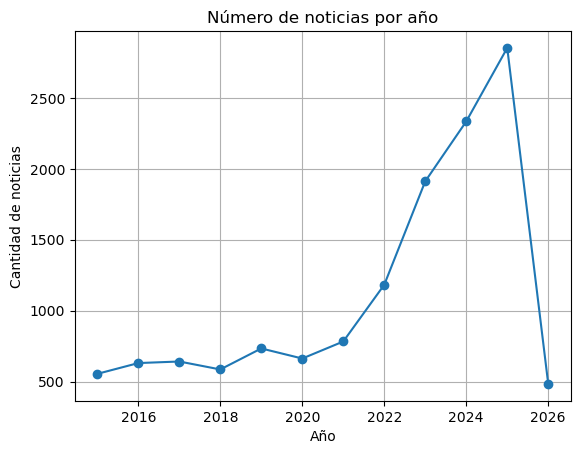

In [46]:
#Análisis Temporal por año
df_master['Año'].value_counts().sort_index()
#Análisis Temporal por mes 
df_master['Mes'].value_counts()

df_master.groupby('Año').size().plot(kind='line', marker='o')

plt.title('Número de noticias por año')
plt.xlabel('Año')
plt.ylabel('Cantidad de noticias')
plt.grid(True)
plt.show()



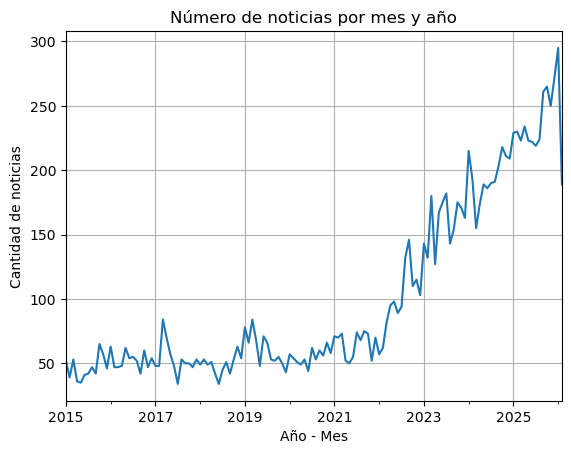

In [54]:
# Pasar mes a número
meses = {
    'Enero': 1, 'Febrero': 2, 'Marzo': 3, 'Abril': 4,
    'Mayo': 5, 'Junio': 6, 'Julio': 7, 'Agosto': 8,
    'Septiembre': 9, 'Octubre': 10, 'Noviembre': 11, 'Diciembre': 12
}

df_master['Mes_num'] = df_master['Mes'].map(meses)

# Crear Año-Mes
df_master['AñoMes'] = pd.to_datetime(
    dict(year=df_master['Año'], month=df_master['Mes_num'], day=1)
)
# Agrupar y Graficar
df_master.groupby('AñoMes').size().plot(kind='line')

plt.title('Número de noticias por mes y año')
plt.xlabel('Año - Mes')
plt.ylabel('Cantidad de noticias')
plt.grid(True)
plt.show()


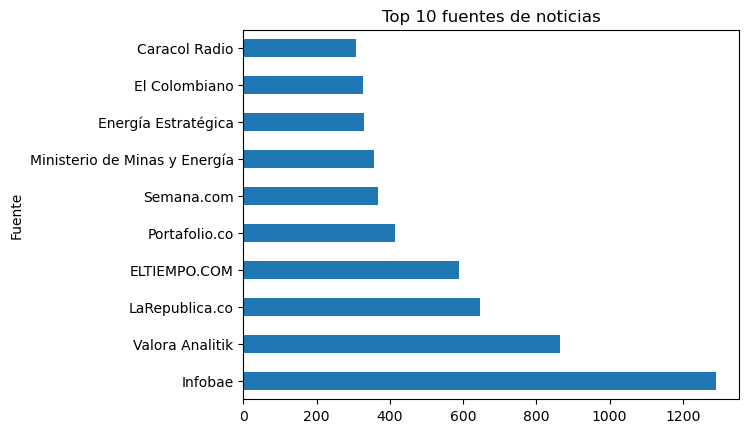

In [ ]:
# Análsis por Fuente
df_master['Fuente'].value_counts().head(10)
df_master['Fuente'].value_counts().head(10).plot(kind='barh')
plt.title('Top 10 fuentes de noticias')
plt.show()

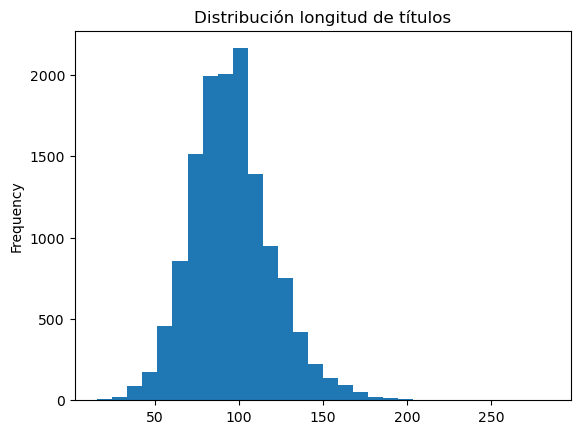

In [61]:
# Análisis textual básico del título
df_master['len_titulo'] = df_master['Titulo'].str.len()
df_master['len_titulo'].describe()
df_master['len_titulo'].plot(kind='hist', bins=30)
plt.title('Distribución longitud de títulos')
plt.show()



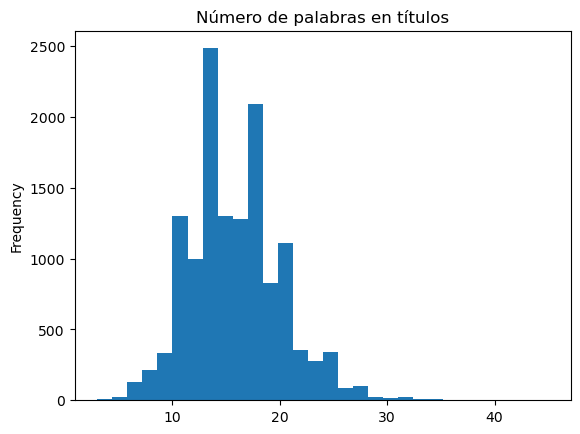

In [64]:
df_master['num_palabras'] = df_master['Titulo'].str.split().str.len()
df_master['num_palabras'].plot(kind='hist', bins=30)
plt.title('Número de palabras en títulos')
plt.show()


In [67]:
# Palabras Frecuentes
from collections import Counter

texto = ' '.join(df_master['Titulo'].dropna()).lower()
palabras = texto.split()
Counter(palabras).most_common(20)


[('de', 14292),
 ('-', 13549),
 ('en', 8286),
 ('el', 7310),
 ('la', 6730),
 ('colombia', 4232),
 ('y', 4077),
 ('energía', 3464),
 ('a', 2734),
 ('del', 2557),
 ('para', 2241),
 ('que', 2163),
 ('los', 1872),
 ('por', 1756),
 ('las', 1599),
 ('con', 1371),
 ('se', 1315),
 ('infobae', 1290),
 ('más', 1168),
 ('un', 1061)]

In [70]:
#Análisis por Query
df_master['Query'].value_counts()


Query
energía Colombia                                        7512
fenómeno del Niño Colombia                              2412
fenómeno de la Niña Colombia                            1542
demanda oferta energía Colombia mercado eléctrico        497
generación hidroeléctrica sistema eléctrico Colombia     482
precio energía bolsa mercado eléctrico Colombia          459
mercado futuros energía Colombia                         443
XM CREG operación mercado eléctrico Colombia              12
Name: count, dtype: int64

In [71]:
{
    "Total noticias": len(df_master),
    "Fuentes únicas": df_master['Fuente'].nunique(),
    "Queries usadas": df_master['Query'].nunique(),
    "Noticias con hora": df_master['Hora'].notna().mean(),
}


{'Total noticias': 13359,
 'Fuentes únicas': 1055,
 'Queries usadas': 8,
 'Noticias con hora': np.float64(1.0)}

## Procesamiento de Texto ##

In [74]:
# Limpieza y normalización de Texto
import re

df_master['titulo_clean'] = (
    df_master['Titulo']
    .str.lower()
    .str.replace(r'http\S+', '', regex=True)
    .str.replace(r'[^a-záéíóúñü\s]', '', regex=True)
    .str.strip()
)


In [75]:
#Palabras más frecuentes
from collections import Counter

texto = ' '.join(df_master['titulo_clean'].dropna())
palabras = texto.split()

Counter(palabras).most_common(20)


[('de', 14322),
 ('en', 8343),
 ('el', 7433),
 ('la', 6834),
 ('colombia', 5175),
 ('y', 4098),
 ('energía', 3674),
 ('a', 2770),
 ('del', 2560),
 ('para', 2253),
 ('que', 2172),
 ('por', 1913),
 ('los', 1892),
 ('las', 1616),
 ('con', 1384),
 ('se', 1351),
 ('infobae', 1290),
 ('más', 1187),
 ('un', 1083),
 ('colombiano', 988)]

In [78]:
# STOPWORDS
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords
stop_words = set(stopwords.words('spanish'))

palabras_filtradas = [w for w in palabras if w not in stop_words]
Counter(palabras_filtradas).most_common(20)


[nltk_data] Downloading package stopwords to C:\Users\Jhon Fernando
[nltk_data]     Tascón\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


[('colombia', 5175),
 ('energía', 3674),
 ('infobae', 1290),
 ('colombiano', 988),
 ('valora', 868),
 ('analitik', 867),
 ('fenómeno', 860),
 ('niño', 694),
 ('larepublicaco', 645),
 ('radio', 615),
 ('solar', 614),
 ('eltiempocom', 588),
 ('minas', 558),
 ('portafolioco', 555),
 ('energética', 554),
 ('eléctrica', 544),
 ('país', 543),
 ('gobierno', 521),
 ('bogotá', 516),
 ('ministerio', 496)]

In [82]:
# N-GRAMAS
from nltk import ngrams

bigrams = ngrams(palabras_filtradas,2)
Counter(bigrams).most_common(15)


[(('valora', 'analitik'), 867),
 (('minas', 'energía'), 492),
 (('fenómeno', 'niño'), 447),
 (('ministerio', 'minas'), 430),
 (('energía', 'estratégica'), 329),
 (('caracol', 'radio'), 309),
 (('colombiano', 'colombiano'), 305),
 (('energía', 'colombia'), 301),
 (('enel', 'colombia'), 296),
 (('energía', 'solar'), 285),
 (('fenómeno', 'niña'), 271),
 (('transición', 'energética'), 260),
 (('energías', 'renovables'), 245),
 (('contexto', 'ganadero'), 244),
 (('colombia', 'valora'), 205)]

In [95]:
  #Clasificación temática (Reglas simples) 
def clasificar_tema(t):
    if any(w in t for w in ['precio', 'tarifa', 'costo']):
        return 'Precios'
    elif any(w in t for w in ['creg', 'regulación', 'resolución']):
        return 'Regulación'
    elif any(w in t for w in ['apagón', 'racionamiento', 'fallas']):
        return 'Crisis'
    elif any(w in t for w in ['hidrología', 'niño', 'clima']):
        return 'Clima'
    elif any(w in t for w in ['energía', 'energetico', 'electricidad']):
        return 'energía'
    else:
        return 'Otros'

df_master['tema'] = df_master['titulo_clean'].apply(clasificar_tema)


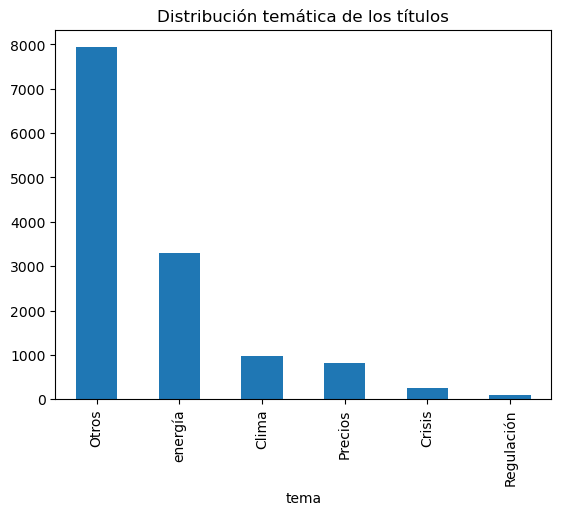

In [96]:
df_master['tema'].value_counts().plot(kind='bar')
plt.title('Distribución temática de los títulos')
plt.show()


## Análisis de Sentimiento (Títulos Cortos) ##

In [88]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=1000,
    ngram_range=(1,2)
)

X = vectorizer.fit_transform(df_master['titulo_clean'])



In [90]:
# Preparar Texto
X_text = df_master['titulo_clean'].dropna()

# Vecorización (TF-IDF con n-gramas)
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=2000,
    ngram_range=(1,2),
    min_df=5
)

X_tfidf = vectorizer.fit_transform(X_text)


In [91]:
# Clustering (No supervisado)
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_tfidf)

df_master.loc[X_text.index, 'cluster'] = clusters


In [93]:
import numpy as np

terms = vectorizer.get_feature_names_out()

for i in range(5):
    top_terms = np.argsort(kmeans.cluster_centers_[i])[-10:]
    print(f"Cluster {i}: {[terms[t] for t in top_terms]}")


Cluster 0: ['para', 'los', 'que', 'del', 'energía', 'colombia', 'el', 'la', 'en', 'de']
Cluster 1: ['el fenómeno', 'la niña', 'niña', 'de el', 'de', 'el niño', 'fenómeno de', 'niño', 'el', 'fenómeno']
Cluster 2: ['la', 'en', 'de', 'carro colombiano', 'el carro', 'carro', 'colombiano el', 'el', 'el colombiano', 'colombiano']
Cluster 3: ['el', 'en', 'la', 'energía', 'de', 'ministerio', 'ministerio de', 'minas energía', 'minas', 'de minas']
Cluster 4: ['la', 'para', 'en colombia', 'colombia', 'en', 'colombia valora', 'de', 'valora', 'valora analitik', 'analitik']


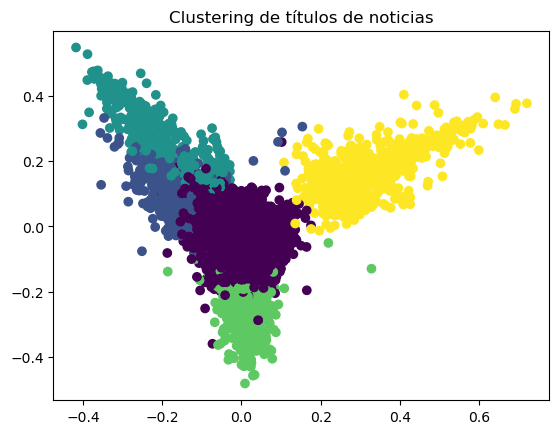

In [94]:
from sklearn.decomposition import PCA

X_pca = PCA(n_components=2).fit_transform(X_tfidf.toarray())

plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters)
plt.title('Clustering de títulos de noticias')
plt.show()


## Modelo Transformer ##

In [97]:
# Limpieza del texto
df_master['titulo_sent'] = (
    df_master['Titulo']
    .str.lower()
    .str.replace(r'http\S+', '', regex=True)
    .str.replace(r'[^a-záéíóúñü\s]', '', regex=True)
    .str.strip()
)


In [100]:
# Modelo de Sentimiento en Español
#!pip install transformers torch

from transformers import pipeline

sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment"
)


02/09/2026 06:28:34 PM - HTTP Request: HEAD https://huggingface.co/nlptown/bert-base-multilingual-uncased-sentiment/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
02/09/2026 06:28:34 PM - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/nlptown/bert-base-multilingual-uncased-sentiment/8f6f4e3a8f70be4b65d3a4a8762b6d781cda240d/config.json "HTTP/1.1 200 OK"
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1065.00it/s, Materializing param=classifier.weight]                                     
02/09/2026 06:28:34 PM - HTTP Request: GET https://huggingface.co/api/models/nlptown/bert-base-multilingual-uncased-sentiment/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
02/09/2026 06:28:35 PM - HTTP Request: GET https://huggingface.co/api/models/nlptown/bert-base-multilingual-uncased-sentiment/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
02/09/2026 06:28:35 PM - HTTP Request: GET https://huggingface.co/api/

In [101]:
# Obtener el Sentimiento
df_master['sentimiento_raw'] = df_master['titulo_sent'].apply(
    lambda x: sentiment_pipeline(x)[0]
)


In [102]:
def map_sentiment(label):
    return int(label.split()[0])

df_master['sentimiento'] = df_master['sentimiento_raw'].apply(
    lambda x: map_sentiment(x['label'])
)


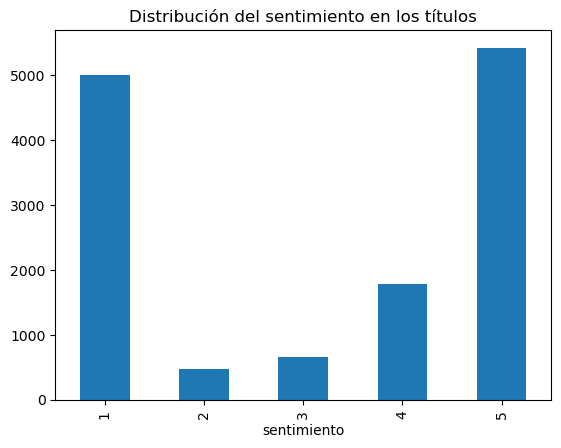

In [103]:
df_master['sentimiento'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribución del sentimiento en los títulos')
plt.show()


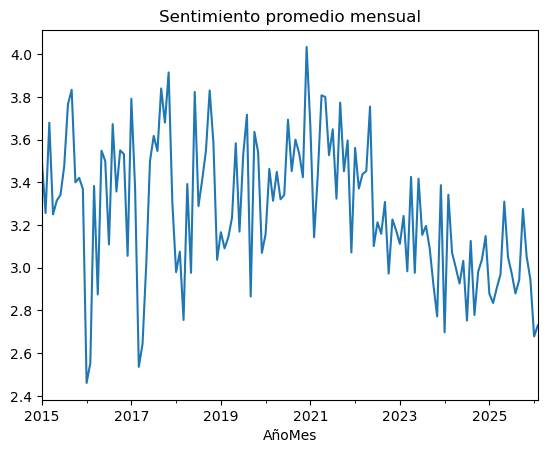

In [104]:
df_master.groupby('AñoMes')['sentimiento'].mean().plot(kind='line')
plt.title('Sentimiento promedio mensual')
plt.show()


In [108]:
df_master.head()

,Query,Titulo,Fuente,Fecha,url,Hora,Año,Mes,Dia,Dia_semana,Mes_num,AñoMes,len_titulo,num_palabras,titulo_clean,tema,cluster,titulo_sent,sentimiento_raw,sentimiento
0,energía Colombia,Llega el agua para La Guajira a traves de exca...,Minvivienda,2015-01-17,https://news.google.com/rss/articles/CBMiwAFBV...,00:00:00,2015,Enero,17,Sábado,1,2015-01-01,97,16,llega el agua para la guajira a traves de exca...,Otros,0.0,llega el agua para la guajira a traves de exca...,"{'label': '5 stars', 'score': 0.2775818109512329}",5
1,energía Colombia,Reforma tributaria - Ley 1739 de 2014 - Hollan...,Holland & Knight,2015-01-27,https://news.google.com/rss/articles/CBMilgFBV...,00:00:00,2015,Enero,27,Martes,1,2015-01-01,56,11,reforma tributaria ley de holland knight,Otros,0.0,reforma tributaria ley de holland knight,"{'label': '3 stars', 'score': 0.24879030883312...",3
2,energía Colombia,"""Hidrosogamoso nos aleja de un racionamiento d...",Vanguardia,2015-01-15,https://news.google.com/rss/articles/CBMixAFBV...,00:00:00,2015,Enero,15,Jueves,1,2015-01-01,88,14,hidrosogamoso nos aleja de un racionamiento de...,Crisis,0.0,hidrosogamoso nos aleja de un racionamiento de...,"{'label': '1 star', 'score': 0.30076849460601807}",1
3,energía Colombia,La colombiana Edemsa ganó contrato de energía ...,Semana.com,2015-01-25,https://news.google.com/rss/articles/CBMisAFBV...,00:00:00,2015,Enero,25,Domingo,1,2015-01-01,68,11,la colombiana edemsa ganó contrato de energía ...,energía,0.0,la colombiana edemsa ganó contrato de energía ...,"{'label': '1 star', 'score': 0.3012270927429199}",1
4,energía Colombia,"A falta de melaza para el ganado, ¿bueno es el...",CONtexto Ganadero,2015-01-19,https://news.google.com/rss/articles/CBMirAFBV...,00:00:00,2015,Enero,19,Lunes,1,2015-01-01,79,14,a falta de melaza para el ganado bueno es el c...,Otros,1.0,a falta de melaza para el ganado bueno es el c...,"{'label': '3 stars', 'score': 0.505180299282074}",3


In [10]:
ruta = "noticias_energia_CO_limpio_v1.csv"
dff_master = pd.read_csv(ruta)

In [11]:
dff_master.dtypes

Query         object
Titulo        object
Fuente        object
Fecha         object
url           object
Hora          object
Año            int64
Mes           object
Dia            int64
Dia_semana    object
dtype: object

In [12]:
dff_master = dff_master.drop_duplicates(
    subset=['Titulo', 'Fuente', 'Fecha']
)


In [17]:
dff_master['Fecha'] = pd.to_datetime(
    dff_master['Fecha'], errors='coerce'
)

dff_master['Hora'] = pd.to_datetime(
    dff_master['Hora'], errors='coerce'
).dt.time
dff_master = dff_master.dropna(subset=['Fecha'])

dff_master.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13452 entries, 0 to 13958
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Query       13452 non-null  object        
 1   Titulo      13452 non-null  object        
 2   Fuente      13452 non-null  object        
 3   Fecha       13452 non-null  datetime64[ns]
 4   url         13452 non-null  object        
 5   Hora        0 non-null      datetime64[ns]
 6   Año         13452 non-null  int64         
 7   Mes         13452 non-null  object        
 8   Dia         13452 non-null  int64         
 9   Dia_semana  13452 non-null  object        
dtypes: datetime64[ns](2), int64(2), object(6)
memory usage: 1.1+ MB


In [119]:
def limpiar_titulo(texto):
    texto = texto.lower()
    texto = unicodedata.normalize('NFKD', texto)\
        .encode('ascii', 'ignore')\
        .decode('utf-8')

    texto = re.sub(r'http\S+', '', texto)
    texto = re.sub(r'\d+', '', texto)
    texto = re.sub(r'[^a-z\s]', '', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()

    return texto

In [121]:
dff_master['titulo_limpio'] = dff_master['Titulo'].apply(limpiar_titulo)
dff_master = dff_master[
    dff_master['titulo_limpio'].str.split().str.len() >= 3
]


In [122]:
def limpiar_fuente(fuente):
    if pd.isna(fuente):
        return None
    fuente = fuente.lower().strip()
    fuente = fuente.replace('.com', '')
    fuente = fuente.replace('.co', '')
    fuente = fuente.replace('-', ' ')
    fuente = ' '.join(fuente.split())
    return fuente

dff_master['fuente_limpia'] = dff_master['Fuente'].apply(limpiar_fuente)


In [123]:
map_fuentes = {
    'eltiempo': 'el tiempo',
    'el tiempo colombia': 'el tiempo',
    'rcn noticias': 'rcn',
    'caracol radio': 'caracol',
    'portafolio co': 'portafolio'
}

dff_master['fuente_limpia'] = dff_master['fuente_limpia'].replace(map_fuentes)


In [125]:
noticias_fuente_anio = (
    dff_master
    .groupby(['fuente_limpia', 'Año'])
    .size()
    .reset_index(name='cantidad_noticias')
    .sort_values(['Año', 'cantidad_noticias'], ascending=[True, False])
)

noticias_fuente_anio



,fuente_limpia,Año,cantidad_noticias
513,contexto ganadero,2015,46
1622,larepublica,2015,35
2359,semana,2015,24
803,el colombiano,2015,20
294,bogota.gov,2015,17
...,...,...,...
2641,vivir en el poblado,2026,1
2660,wapa.pe,2026,1
2719,xataka smart home,2026,1
2729,yahoo finanzas,2026,1


In [127]:
noticias_fuente_ano = (
    dff_master
    .groupby(['fuente_limpia', 'Año'])
    .size()
    .reset_index(name='cantidad_noticias')
    .sort_values(['fuente_limpia', 'Año'])
)

noticias_fuente_ano


,fuente_limpia,Año,cantidad_noticias
0,.: el sol de margarita :.,2016,1
1,180.uy,2016,1
2,2001 online,2026,1
3,20minutos,2021,1
4,20minutos,2025,1
...,...,...,...
2741,ámbito jurídico,2021,2
2742,ámbito jurídico,2023,2
2743,ámbito jurídico,2024,1
2744,ámbito jurídico,2025,2


In [175]:
noticias_por_fuente = (
    dff_master
    .groupby('fuente_limpia')
    .size()
    .reset_index(name='cantidad_noticias')
    .sort_values('cantidad_noticias', ascending=False)
)

noticias_por_fuente.head(30)


,fuente_limpia,cantidad_noticias
299,infobae,1291
574,valora analitik,864
346,larepublica,644
450,portafolio,620
205,el tiempo,589
518,semana,368
381,ministerio de minas y energía,357
231,energía estratégica,329
170,el colombiano,327
83,caracol,307


In [154]:
conteo_por_fuente = (
    dff_master
    .groupby('fuente_limpia')
    .size()
)
acumulado = 0
resultados = []

for i in range(1, 51):
    fuentes = conteo_por_fuente[conteo_por_fuente == i].index.tolist()
    cantidad_fuentes = len(fuentes)
    
    acumulado += cantidad_fuentes
    
    resultados.append({
        'cantidad_noticias': i,
        'numero_fuentes': cantidad_fuentes,
        'acumulado_fuentes': acumulado,
        'fuentes': fuentes
    })

df_distribucion = pd.DataFrame(resultados)
df_distribucion



,cantidad_noticias,numero_fuentes,acumulado_fuentes,fuentes
0,1,28,28,"[adres.gov, aristeguinoticias, biobiochile, ca..."
1,2,151,179,"[20minutos, abc, alba ciudad, alcaldía distrit..."
2,3,86,265,"[actualícese, afp factual, agencia de sostenib..."
3,4,66,331,"[abceconomia, agencia peruana de noticias | an..."
4,5,42,373,"[acento, alcaldía de barrancabermeja, alcaldía..."
5,6,38,411,"[acr latinoamérica, al poniente, alerta, amazo..."
6,7,17,428,"[corficolombiana, correo del caroní, cultura, ..."
7,8,19,447,"[banca y negocios, blogs el tiempo, colombia i..."
8,9,12,459,"[boyacá 7 días, crónica del quindio, diario.el..."
9,10,7,466,"[df sud, el blog salmón, enel green power, la ..."


In [130]:
total_fuentes = dff_master['fuente_limpia'].nunique()
total_fuentes

1047

In [158]:
conteo_por_fuente = dff_master['fuente_limpia'].value_counts()
fuentes_una_noticia = conteo_por_fuente[conteo_por_fuente == 1].index
df_fuentes_una = dff_master[
    dff_master['fuente_limpia'].isin(fuentes_una_noticia)
]
for fuente, titulo in zip(df_fuentes_una['fuente_limpia'], df_fuentes_una['Titulo']):
    print(f"Fuente: {fuente} | Título: {titulo}")


Fuente: distintas latitudes | Título: Fracking, comunidades en riesgo e hidroeléctricas en Colombia; una entrevista con Mariana Fajardo - Distintas Latitudes
Fuente: international renewable energy agency (irena) | Título: Evaluación de la Flexibilidad del Sistema Eléctrico de Colombia - International Renewable Energy Agency (IRENA)
Fuente: wärtsilä | Título: La central eléctrica de 200 MW de Wärtsilä proporcionará energía crítica para equilibrar y respaldar la red nacional en Colombia. - Wärtsilä
Fuente: ministerio de comercio, industria y turismo | Título: Dos beneficios al turismo se aprueban en Proyecto de Ley de Inversión Social - Ministerio de Comercio, Industria y Turismo
Fuente: international hydropower association (iha) | Título: Colombia, como uno de los líderes latinoamericanos en energía hidroeléctrica, le apuesta a la aplicación de un estándar mundial de sostenibilidad. - International Hydropower Association (IHA)
Fuente: crowe | Título: Transición Energética: Lecciones nor

In [ ]:
# Paso 1: identificar fuentes con 1 noticia
conteo_por_fuente = dff_master['fuente_limpia'].value_counts()
fuentes_una_noticia = conteo_por_fuente[conteo_por_fuente == 1].index

# Paso 2: filtrar DataFrame
df_fuentes_una = dff_master[dff_master['fuente_limpia'].isin(fuentes_una_noticia)]

# Paso 3: seleccionar solo las columnas que queremos
df_export = df_fuentes_una[['fuente_limpia', 'Titulo']]

# Paso 4: exportar a CSV
df_export.to_csv('fuentes_con_una_noticia.csv', index=False, encoding='utf-8-sig')

print(f"Archivo exportado con {len(df_export)} registros.")
#-------------------------------------------------------------------#
# Paso 1: identificar fuentes con 2 noticias
conteo_por_fuente = dff_master['fuente_limpia'].value_counts()
fuentes_una_noticia = conteo_por_fuente[conteo_por_fuente == 2].index

# Paso 2: filtrar DataFrame
df_fuentes_una = dff_master[dff_master['fuente_limpia'].isin(fuentes_una_noticia)]

# Paso 3: seleccionar solo las columnas que queremos
df_export = df_fuentes_una[['fuente_limpia', 'Titulo']]

# Paso 4: exportar a CSV
df_export.to_csv('fuentes_con_dos_noticia.csv', index=False, encoding='utf-8-sig')

print(f"Archivo exportado con {len(df_export)} registros.")

Archivo exportado con 28 registros.
Archivo exportado con 302 registros.


In [150]:
#Eliminar fuentes
fuentes_eliminar = [
    "facultad de gobierno udd",
    "perspectiva.gt",
    "canal 13",
    "izquierda diario.es",
    "news is my business",
    "américa latina en movimiento",
    "heraldo.es",
    "máspormás",
    "poblanerias",
    "diario avance",
    "teletrece",
    "plaza pública",
    "primera hora",
    "elentrerios",
    "la ruta del clima",
    "defensa",
    "minería en línea",
    "actualidad ambiental",
    "excelencias del motor",
    "eldiario.es",
    "residuos profesional",
    "aprendemas",
    "centro urbano",
    "iluminet revista de iluminación",
    "diario sustentable",
    "noticine",
    "bolsamania",
    "rockombia",
    "elonce",
    "coches",
    "cápsulas de carreño",
    ".: el sol de margarita :.",
    "ap news",
    "noticias bancarias",
    "diariorenovables",
    "marketing registrado",
    "la revista actual",
    "el patagónico",
    "diario jornada",
    "mutantes tv",
    "fundación telefónica españa",
    "lamega",
    "www.gub.uy",
    "ecoavant",
    "cz comunicación",
    "el potosí",
    "cultura inquieta",
    "nexofin",
    "udenar periódico",
    "desinformémonos",
    "alba ciudad 96.3 fm",
    "the clinic",
    "onda cero radio",
    "noticias positivas",
    "lawyerpress news",
    "gualeguaychu.gov.ar",
    "eju.tv",
    "cmtv.ar",
    "lamarea",
    "solar latin club",
    "autodato",
    "tecache.cl",
    "fundación terram",
    "180.uy",
    "soy502",
    "maestro de la computación",
    "tvyvideo",
    "kapital stereo 107.3 fm",
    "confilegal",
    "acciona",
    "diario la capital de mar del plata",
    "c5n",
    "caras",
    "www.diariopopular.ar",
    "avinews",
    "guioteca",
    "escambray",
    "red bull",
    "scielo.cl",
    "pressenza international press agency",
    "economipedia",
    "perú retail",
    "tec.ac.cr",
    "gestiopolis",
    "adelante inicio",
    "university of wisconsin–madison",
    "venezuelasinfonica",
    "in neuquén",
    "onexpo nacional",
    "peru",
    "instituto distrital de las artes idartes",
    "argentina.gob.ar",
    "diario armenia",
    "meer | english edition",
    "malevamag",
    "espíritu racer",
    "el pitazo",
    "bae negocios",
    "industry & energy magazine",
    "eldoce.tv",
    "efe agencia de noticias",
    "chequeado",
    "subrayado.uy",
    "dj mag latinoamérica",
    "viaja por colombia",
    "reporte asia",
    "transmilenio",
    "uber",
    "primertiempo",
    "daily coffee news by roast magazine",
    "gov.uk",
    "grupo sura",
    "la verdad panamá",
    "el quindiano",
    "global citizen",
    "periodismo público",
    "ceoe",
    "socialgeek",
    "soacha ilustrada",
    "sabersinfin",
    "la voz de yopal",
    "viveelmeta",
    "lalupa.pe",
    "www.metrolibre",
    "mckinsey & company",
    "efeminista",
    "a la luz pública",
    "diario de burgos",
    "segib: secretaría general iberoamericana",
    "ccs.org",
    "korea.net",
    "reporte minero",
    "fashionunited",
    "startupeable",
    "parques nacionales naturales",
    "foro nuclear",
    "el derecho",
    "cajar",
    "el pais vallenato",
    "agencia nova",
    "industria avícola",
    "xataka ciencia",
    "leanotas",
    "con criterio",
    "climate and clean air coalition (ccac)",
    "asociacion peruana de agentes maritimos",
    "partido de la u",
    "nordex se",
    "revista summa",
    "scouts for sdgs",
    "agencia de noticias yonhap",
    "ministerio de comercio",
    "connectas",
    "cuestión pública",
    "cdecomunicacion.es",
    "aristegui noticias",
    "teatro mayor julio mario santo domingo",
    "forbes perú",
    "bocadepozo.ar",
    "apple",
    "peru construye",
    "criptonoticias",
    "enel chile",
    "una.py",
    "universidad politécnica de cartagena",
    "aceprensa",
    "byd",
    "publinews",
    "la otra verdad",
    "bioeconomia.info",
    "universidad del magdalena",
    "ovacen",
    "cámara de comercio de bilbao",
    "mininterior.gov",
    "salud con lupa",
    "revista momentos",
    "universidad veracruzana",
    "transparencia por colombia",
    "infodefensa",
    "grupo bimbo",
    "jetnews.mx",
    "micanal2.tv",
    "alta densidad",
    "unidades tecnológicas de santander",
    "emcali",
    "agencia de noticias tierra viva",
    "transmisoraquindio",
    "metro de medellín",
    "cámara de representantes",
    "expo med hub",
    "alcaldía de pereira",
    "afd agence française de développement",
    "aci prensa",
    "think big empresas",
    "350.org",
    "alcaldía mayor de cartagena",
    "el expediente",
    "anthesis group",
    "global seafood alliance",
    "jacobin revista",
    "notasdeactualidad",
    "international council on clean transportation",
    "phenomenal world",
    "pasto.gov",
    "migueluribe",
    "ember energy.org",
    "euronews",
    "contrapunto.sv",
    "savethechildren.es",
    "sony music españa",
    "lópez dóriga digital",
    "ecoportal.net",
    "sinembargo.mx",
    "wwf méxico",
    "mundo deportivo",
    "universidad nacional del litoral (unl)",
    "agenzia fides",
    "modaes",
    "cctv english",
    "candelaestereo",
    "cubahora",
    "equal times",
    "agrositio",
    "acnur.org",
    "el bocón",
    "ocio latino",
    "agronegociosperu.org",
    "rcr peru",
    "cb24.tv",
    "digame",
    "medicina y salud pública",
    "bebés y más",
    "cooperativa.cl",
    "el mostrador",
    "esquire",
    "alcaldía local de san cristóbal",
    "ong manos unidas",
    "insight crime",
    "esprit automation",
    "diario libero",
    "el independiente",
    "hispanos press",
    "conarte nuevo león",
    "creaf",
    "rta noticias",
    "nordex online",
    "mamaslatinas",
    "david noticias",
    "banco de la república",
    "la prensa noticias de nicaragua y el mundo",
    "mundotoro",
    "minagricultura.gov",
    "noticiascoopercom",
    "nbc news",
    "diario del norte",
    "la voz de lanzarote",
    "playgroundweb",
    "diario constitucional",
    "viviendosantaelena",
    "onic.org",
    "depor",
    "el armadillo",
    "centro de información – alcaldía de manizales",
    "interpol",
    "3djuegos latam",
    "meteored españa",
    "runrun.es",
    "listín diario",
    "el montonero",
    "ladera sur",
    "misiones salesianas",
    "tv pública",
    "trome",
    "la web de la salud",
    "somosnews.mx",
    "santander.gov",
    "instituto de democracia y derechos humanos pucp",
    "cartagena.alerta",
    "archivogeneral.gov",
    "notipress",
    "orientese co",
    "argenpapa",
    "cornare",
    "mincultura.gov.",
    "diario la libertad",
    "justiceinfo.net",
    "elirreverenteibague",
    "nación321",
    ":.periodicovirtual.:",
    "unidad para las víctimas",
    "elnortehoy",
    "abcnoticias.mx",
    "unir",
    "unicef españa",
    "hchr.org",
    "eacnur.org",
    "monumental.cr",
    "el economista: últimas noticias económicas y financieras",
    "onda cero",
    "escudo digital",
    "emisoras unidas",
    "la 100",
    "sinc",
    "canal tro",
    "ctxt.es",
    "meridiano70",
    "agrofy news",
    "secom.es",
    "wapa.pe",
    "página 7",
    "prensarural.org",
    "wwf perú",
    "meteorología en red",
    "angelicalozano",
    "urgentebo",
    "people en español",
    "cerosetenta",
    "noticias 625",
    "don tamalio",
    "alcaldía de armenia",
    "lacontaminacion.org",
    "lapatria.bo",
    "es.wfp.org",
    "eldiario",
    "avicultura",
    "hola",
    "alcaldía de bucaramanga",
    "colombia visible",
    "radio fe y alegría noticias",
    "bolivia",
    "miredvista",
    "radioconexionanimal",
    "artículo 66",
    "gente",
    "viva nicaragua canal 13",
    "sucrenoticias",
    "sbs australia",
    "nasa ciencia (.gov)",
    "dataexport.gt",
    "tn",
    "lavozdelaregion",
    "concejodecali.gov",
    "el litoral",
    "emisora ondas de ibagué",
    "noticias rptv",
    "alcaldía de santiago de cali",
    "yale climate connections",
    "portalnews",
    "world meteorological organization wmo",
    "gobernación de risaralda",
    "ayudas 10",
    "meteored.mx",
    "reforma",
    "código san luis",
    "qpasa",
    "preventionweb.net",
    "caracoltv",
    "h13n",
    "insurgencia magisterial",
    "emisora nueva época",
    "diario del sur noticias de hoy",
    "radiohoy",
    "2001 online",
    "irena – international renewable energy agency",
    "elmercurio.ec",
    "z 101 digital",
    "letra p",
    "ventevenezuela.org",
    "universidad de navarra",
    "blogs.gestion.pe",
    "cotejo.info",
    "elsurti",
    "construyendo.pe",
    "el mexicano.mx",
    "ultimasnoticias.ve",
    "noticias de loja – ecuador",
    "periódico 26",
    "viu españa",
    "economía sustentable",
    "los40.mx",
    "diario la verdad de vargas",
    "upinforma",
    "laradiodelsur.ve",
    "bolsadigital.org",
    "forbes españa",
    "información",
    "mitrade",
    "invertir online",
    "auto test",
    "crónica global",
    "lapoliticaonline",
    "energelia",
    "tradingview",
    "ecosiglos",
    "economistas frente a la crisis",
    "energymagazine.mx",
    "forex",
    "moeveglobal",
    "santander",
    "fenavi.ve",
    "vaneck",
    "código prensa",
    "marca chile",
    "investing español",
    "technocio",
    "real instituto elcano",
    "edenred",
    "el futbolero colombia",
    "j.p. morgan private bank",
    "stakeholders.pe",
    "in salta",
    "enersa",
    "ebc financial group",
    "ministerio de la presidencia de panamá",
    "txs+",
    "idealista",
    "perfil",
    "terra colombia",
    "delfino.cr",
    "republica",
    "radio jgm",
    "murciaeconomia",
    "endesa",
    "semanario universidad",
    "larepublica.net",
    "noticiastrabajo",
    "smartgridsinfo",
    "business model analyst",
    "global voices en español",
    "alertadigital.ar",
    "revista minería & energía",
    "businesscol",
    "xataka méxico",
    "el salto",
    "cushman & wakefield",
    "el nacional.cat",
    "maldita.es",
    "méxico ¿cómo vamos?",
    "capitalmadrid",
    "blasina y asociados",
    "icndiario",
    "impactamag",
    "noticias.madrid"
]
dff_master = dff_master[
    ~dff_master['fuente_limpia'].isin(fuentes_eliminar)
].copy()


In [163]:
dff_master.head()

,Query,Titulo,Fuente,Fecha,url,Hora,Año,Mes,Dia,Dia_semana,titulo_limpio,impacto_comprador,fuente_limpia
0,energía Colombia,Llega el agua para La Guajira a traves de exca...,Minvivienda,2015-01-17,https://news.google.com/rss/articles/CBMiwAFBV...,NaT,2015,Enero,17,Sábado,llega el agua para la guajira a traves de exca...,None,minvivienda
1,energía Colombia,Reforma tributaria - Ley 1739 de 2014 - Hollan...,Holland & Knight,2015-01-27,https://news.google.com/rss/articles/CBMilgFBV...,NaT,2015,Enero,27,Martes,reforma tributaria ley de holland knight,None,holland & knight
2,energía Colombia,"""Hidrosogamoso nos aleja de un racionamiento d...",Vanguardia,2015-01-15,https://news.google.com/rss/articles/CBMixAFBV...,NaT,2015,Enero,15,Jueves,hidrosogamoso nos aleja de un racionamiento de...,None,vanguardia
3,energía Colombia,La colombiana Edemsa ganó contrato de energía ...,Semana.com,2015-01-25,https://news.google.com/rss/articles/CBMisAFBV...,NaT,2015,Enero,25,Domingo,la colombiana edemsa gano contrato de energia ...,None,semana
4,energía Colombia,"A falta de melaza para el ganado, ¿bueno es el...",CONtexto Ganadero,2015-01-19,https://news.google.com/rss/articles/CBMirAFBV...,NaT,2015,Enero,19,Lunes,a falta de melaza para el ganado bueno es el c...,None,contexto ganadero


In [167]:
len(dff_master)

13005

In [176]:
noticias_por_fuente.head(30)

,fuente_limpia,cantidad_noticias
299,infobae,1291
574,valora analitik,864
346,larepublica,644
450,portafolio,620
205,el tiempo,589
518,semana,368
381,ministerio de minas y energía,357
231,energía estratégica,329
170,el colombiano,327
83,caracol,307


In [187]:
def ver_noticias_por_fuente(df, fuente):
    df_fuente = df[df['fuente_limpia'] == fuente]
    print(f"Fuente: {fuente}")
    print(f"Número de noticias: {len(df_fuente)}\n")
    
    return df_fuente[['Fecha', 'Titulo', 'Query',]]

ver_noticias_por_fuente(dff_master, 'larepublica').head(100)

#Análisis por Query
#df_master['Query'].value_counts()


Fuente: larepublica
Número de noticias: 644



,Fecha,Titulo,Query
21,2015-01-20,Logo de Coca-Cola estará al lado del de Águila...,energía Colombia
31,2015-01-26,"Paulina Vega, la barranquillera que nació con ...",energía Colombia
41,2015-02-03,Menos de 3% de la energía que Colombia consume...,energía Colombia
45,2015-02-07,Cuatro cabeceras en Colombia siguen sin sumini...,energía Colombia
55,2015-02-20,Tres nuevas hidroeléctricas generarán 517 mega...,energía Colombia
...,...,...,...
1638,2018-10-25,La producción de carbón a nivel nacional cae 9...,energía Colombia
1640,2018-10-25,Conozca la historia detrás del nacimiento de E...,energía Colombia
1653,2018-10-12,Esto es lo que debe tener en cuenta a la hora ...,energía Colombia
1670,2018-11-10,Federal tendrá planta de generación de energía...,energía Colombia


In [190]:
dff_sin = dff_master[
    dff_master['Query'] != 'energía Colombia'
].copy()


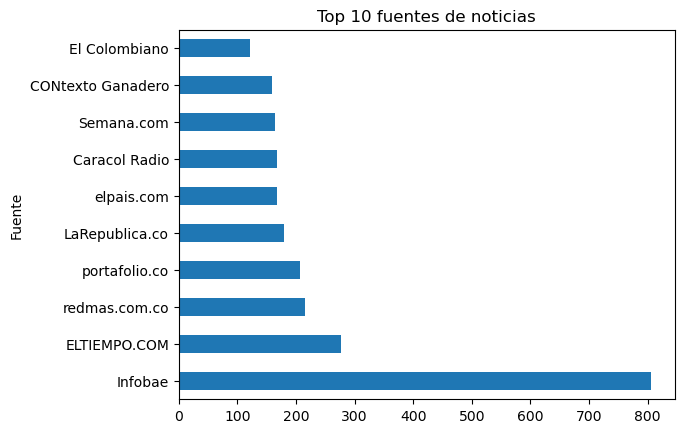

In [194]:
# Análsis por Fuente
dff_sin['Fuente'].value_counts().head(10)
dff_sin['Fuente'].value_counts().head(10).plot(kind='barh')
plt.title('Top 10 fuentes de noticias')
plt.show()

In [199]:
dff_sin[['Query', 'fuente_limpia', 'Titulo']].to_csv(
    'dff_sin_query_fuente_titulo.csv',
    index=False,
    encoding='utf-8-sig'
)

print("Archivo CSV exportado correctamente.")


Archivo CSV exportado correctamente.


In [33]:
ruta1 = "noticias_filtradas_para_DRL.csv"
fil = pd.read_csv(ruta1)
ruta02 = "noticias_relevantes_DRL_filtrado.csv"
fili = pd.read_csv(ruta1)
ruta2 = "noticias_relevantes_DRL_filtrado_modificado.csv"
filt = pd.read_csv(ruta2)

In [21]:
fil.head()

,Query,Titulo,Fuente,Fecha,url,Hora,Año,Mes,Dia,Dia_semana
0,energía Colombia,"""Hidrosogamoso nos aleja de un racionamiento d...",Vanguardia,2015-01-15,https://news.google.com/rss/articles/CBMixAFBV...,00:00:00,2015,Enero,15,Jueves
1,energía Colombia,La colombiana Edemsa ganó contrato de energía ...,Semana.com,2015-01-25,https://news.google.com/rss/articles/CBMisAFBV...,00:00:00,2015,Enero,25,Domingo
2,energía Colombia,El país es octavo en el uso de gas natural veh...,Portafolio.co,2015-01-16,https://news.google.com/rss/articles/CBMiiwFBV...,00:00:00,2015,Enero,16,Viernes
3,energía Colombia,"Ganaderos colombianos pagan, sin saberlo, por ...",CONtexto Ganadero,2015-01-21,https://news.google.com/rss/articles/CBMiugFBV...,00:00:00,2015,Enero,21,Miércoles
4,energía Colombia,Energía solar lleva agua y esperanza a agricul...,energialimpiaparatodos.com,2015-01-21,https://news.google.com/rss/articles/CBMi4gFBV...,00:00:00,2015,Enero,21,Miércoles


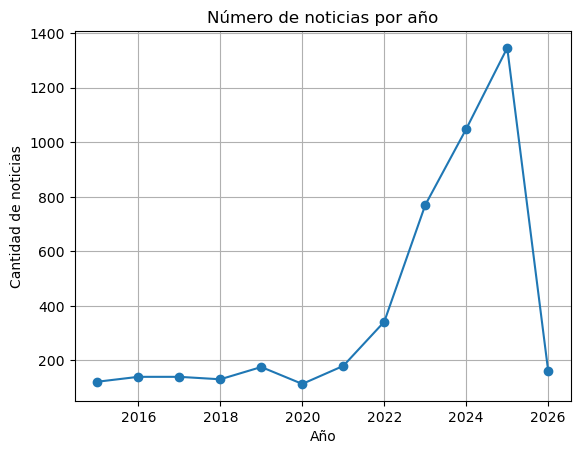

In [22]:
#Análisis Temporal por año
fil['Año'].value_counts().sort_index()
#Análisis Temporal por mes 
fil['Mes'].value_counts()

fil.groupby('Año').size().plot(kind='line', marker='o')

plt.title('Número de noticias por año')
plt.xlabel('Año')
plt.ylabel('Cantidad de noticias')
plt.grid(True)
plt.show()

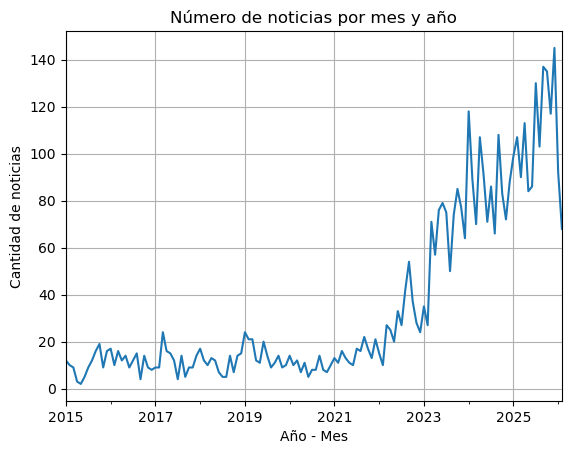

In [23]:
# Pasar mes a número
meses = {
    'Enero': 1, 'Febrero': 2, 'Marzo': 3, 'Abril': 4,
    'Mayo': 5, 'Junio': 6, 'Julio': 7, 'Agosto': 8,
    'Septiembre': 9, 'Octubre': 10, 'Noviembre': 11, 'Diciembre': 12
}

fil['Mes_num'] = fil['Mes'].map(meses)

# Crear Año-Mes
fil['AñoMes'] = pd.to_datetime(
    dict(year=fil['Año'], month=fil['Mes_num'], day=1)
)
# Agrupar y Graficar
fil.groupby('AñoMes').size().plot(kind='line')

plt.title('Número de noticias por mes y año')
plt.xlabel('Año - Mes')
plt.ylabel('Cantidad de noticias')
plt.grid(True)
plt.show()

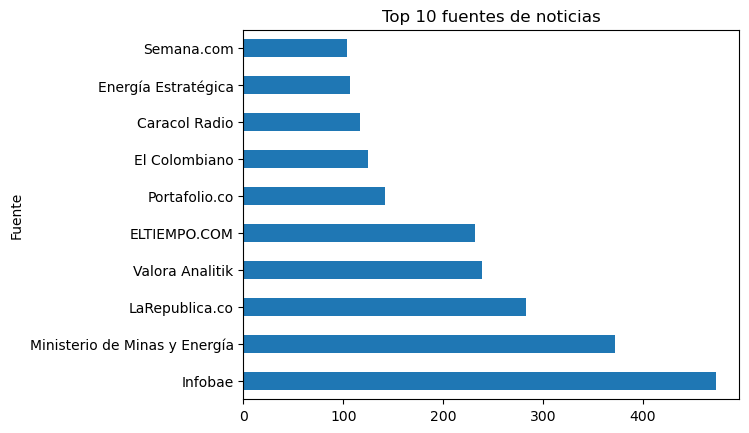

In [24]:
# Análsis por Fuente
fil['Fuente'].value_counts().head(10)
fil['Fuente'].value_counts().head(10).plot(kind='barh')
plt.title('Top 10 fuentes de noticias')
plt.show()

In [ ]:
#Análisis por Query
dff_master['Query'].value_counts()


Query
energía Colombia                                        7513
fenómeno del Niño Colombia                              2438
fenómeno de la Niña Colombia                            1546
demanda oferta energía Colombia mercado eléctrico        516
precio energía bolsa mercado eléctrico Colombia          491
generación hidroeléctrica sistema eléctrico Colombia     489
mercado futuros energía Colombia                         447
XM CREG operación mercado eléctrico Colombia              12
Name: count, dtype: int64

In [30]:
fil.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4670 entries, 0 to 4669
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Query       4670 non-null   object        
 1   Titulo      4670 non-null   object        
 2   Fuente      4670 non-null   object        
 3   Fecha       4670 non-null   object        
 4   url         4670 non-null   object        
 5   Hora        4670 non-null   object        
 6   Año         4670 non-null   int64         
 7   Mes         4670 non-null   object        
 8   Dia         4670 non-null   int64         
 9   Dia_semana  4670 non-null   object        
 10  Mes_num     4670 non-null   int64         
 11  AñoMes      4670 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(3), object(8)
memory usage: 437.9+ KB


In [32]:
fili.head()

,Query,Titulo,Fuente,Fecha,url,Hora,Año,Mes,Dia,Dia_semana
0,energía Colombia,"""Hidrosogamoso nos aleja de un racionamiento d...",Vanguardia,2015-01-15,https://news.google.com/rss/articles/CBMixAFBV...,00:00:00,2015,Enero,15,Jueves
1,energía Colombia,La colombiana Edemsa ganó contrato de energía ...,Semana.com,2015-01-25,https://news.google.com/rss/articles/CBMisAFBV...,00:00:00,2015,Enero,25,Domingo
2,energía Colombia,El país es octavo en el uso de gas natural veh...,Portafolio.co,2015-01-16,https://news.google.com/rss/articles/CBMiiwFBV...,00:00:00,2015,Enero,16,Viernes
3,energía Colombia,"Ganaderos colombianos pagan, sin saberlo, por ...",CONtexto Ganadero,2015-01-21,https://news.google.com/rss/articles/CBMiugFBV...,00:00:00,2015,Enero,21,Miércoles
4,energía Colombia,Energía solar lleva agua y esperanza a agricul...,energialimpiaparatodos.com,2015-01-21,https://news.google.com/rss/articles/CBMi4gFBV...,00:00:00,2015,Enero,21,Miércoles


In [ ]:
import pandas as pd
import unicodedata

df = pd.read_csv("noticias_relevantes_DRL_filtrado.csv")

def normalizar(texto):
    texto = texto.lower()
    texto = unicodedata.normalize('NFD', texto)
    texto = texto.encode('ascii', 'ignore').decode('utf-8')
    return texto

df["Titulo_norm"] = df["Titulo"].astype(str).apply(normalizar)

In [7]:
#Diccionario 
impacto_cnr = {

    # CLIMA (alto impacto estructural)
    "fenomeno del nino": 4,
    "sequía": 4,
    "caida embalses": 4,
    "niveles criticos": 4,

    "lluvias": -3,
    "recuperacion embalses": -4,

    # OFERTA
    "falla": 3,
    "salida de operacion": 3,
    "indisponibilidad": 3,
    "escasez gas": 3,

    "nueva capacidad": -3,
    "aumenta generacion": -3,

    # MERCADO
    "alza": 3,
    "incremento": 3,
    "sube precio": 4,

    "baja precio": -4,
    "reduccion": -3,

    # RIESGO SISTEMICO
    "racionamiento": 5,
    "apagon": 5,
    "crisis energetica": 4
}

In [8]:
def score_cnr(titulo):
    score = 0
    for palabra, peso in impacto_cnr.items():
        if palabra in titulo:
            score += peso
    return score

df["Score_CNR"] = df["Titulo_norm"].apply(score_cnr)

In [9]:
df["Target_CNR"] = (df["Score_CNR"] > 0).astype(int)

In [10]:
print(df[["Titulo", "Score_CNR", "Target_CNR"]].head(20))

print(df["Target_CNR"].value_counts())

                                               Titulo  Score_CNR  Target_CNR
0   "Hidrosogamoso nos aleja de un racionamiento d...          5           1
1   Hidroeléctrica El Quimbo al fin generará desde...          0           0
2   Energía renovable latinoamericana aguanta bajo...          0           0
3   Tres nuevas hidroeléctricas generarán 517 mega...          0           0
4   La hidroeléctrica Bonyic de EPM ya inyecta ene...          0           0
5   Bogotá estrena central hidroeléctrica para gen...          0           0
6   Atentado atribuido a las FARC provoca apagón e...          5           1
7   Llenar el embalse en El Quimbo generó controve...          0           0
8     Emgesa empieza llenado del embalse de El Quimbo          0           0
9   Sector azucarero, potencia en cogeneración de ...          0           0
10  El río de la vida: defensa comunitaria contra ...          0           0
11  151 embalses podrían ser catastróficos para la...          0           0

In [ ]:

df1 = pd.read_csv("ULTIMOS.csv")

In [7]:
df_eliminadas

,Query,Titulo,Fuente,Fecha,url,Hora,Año,Mes,Dia
3,niveles embalses SIN Colombia XM,Aprovechan bajos niveles del embalse Peñol – G...,DiariOriente,2020-06-01,https://news.google.com/rss/articles/CBMirAFBV...,07:00:00,2020,Junio,Lunes
6,niveles embalses SIN Colombia XM,"Demanda de energía de Colombia bajó el 2,60% e...",Semana.com,2021-01-12,https://news.google.com/rss/articles/CBMiogFBV...,08:00:00,2021,Enero,Martes
7,niveles embalses SIN Colombia XM,Generadores dicen que el precio de la energía ...,LaRepublica.co,2022-05-26,https://news.google.com/rss/articles/CBMixAFBV...,07:00:00,2022,Mayo,Jueves
8,niveles embalses SIN Colombia XM,"En noviembre, el embalse de Topocoro cerró con...",Vanguardia,2022-12-15,https://news.google.com/rss/articles/CBMigAJBV...,08:00:00,2022,Diciembre,Jueves
9,niveles embalses SIN Colombia XM,Sigue apagada la segunda turbina de Hidroituan...,Infobae,2023-01-10,https://news.google.com/rss/articles/CBMi2gFBV...,08:00:00,2023,Enero,Martes
...,...,...,...,...,...,...,...,...,...
5417,precio de escasez confiabilidad sistema eléctr...,Colombia supera los 3 gigavatios de energías l...,Ministerio de Minas y Energía,2025-08-20,https://news.google.com/rss/articles/CBMixgFBV...,07:00:00,2025,Agosto,Miércoles
5418,precio de escasez confiabilidad sistema eléctr...,Colombia ya tiene 2 gigas de energías renovabl...,Yahoo,2025-08-20,https://news.google.com/rss/articles/CBMikwFBV...,07:00:00,2025,Agosto,Miércoles
5419,precio de escasez confiabilidad sistema eléctr...,El Gobierno adjudicó contratos de almacenamien...,Infobae,2025-09-01,https://news.google.com/rss/articles/CBMi_gFBV...,07:00:00,2025,Septiembre,Lunes
5420,precio de escasez confiabilidad sistema eléctr...,Plantean lineamientos de política pública para...,Portafolio.co,2025-12-01,https://news.google.com/rss/articles/CBMi5AFBV...,08:00:00,2025,Diciembre,Lunes
